In [4]:
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7,
               31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5,
               34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0,
               38.5, 38.5, 39.5, 41.0, 41.0, 9.8, 10.5, 10.6, 11.0, 11.2,
               11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]

fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0,
               500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0,
               610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0,
               714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
               7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2,
               19.7, 19.9]

In [5]:
import numpy as np

fish_data = np.column_stack((fish_length, fish_weight))
fish_target = np.concatenate((np.ones(35), np.zeros(14)))

print(fish_data[:5])
print(fish_target)

[[ 25.4 242. ]
 [ 26.3 290. ]
 [ 26.5 340. ]
 [ 29.  363. ]
 [ 29.  430. ]]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


In [6]:
from sklearn.model_selection import train_test_split

# 7:3 분리
train_input_7, test_input_7, train_target_7, test_target_7 = train_test_split(
    fish_data, fish_target, test_size=0.3, stratify=fish_target, random_state=42
)

# 5:5 분리
train_input_5, test_input_5, train_target_5, test_target_5 = train_test_split(
    fish_data, fish_target, test_size=0.5, stratify=fish_target, random_state=42
)

# 9:1 분리
train_input_9, test_input_9, train_target_9, test_target_9 = train_test_split(
    fish_data, fish_target, test_size=0.1, stratify=fish_target, random_state=42
)

In [7]:
print(f"[7:3 비율] 훈련 세트: {len(train_input_7)}개, 테스트 세트: {len(test_input_7)}개")
print(f"[5:5 비율] 훈련 세트: {len(train_input_5)}개, 테스트 세트: {len(test_input_5)}개")
print(f"[9:1 비율] 훈련 세트: {len(train_input_9)}개, 테스트 세트: {len(test_input_9)}개")

[7:3 비율] 훈련 세트: 34개, 테스트 세트: 15개
[5:5 비율] 훈련 세트: 24개, 테스트 세트: 25개
[9:1 비율] 훈련 세트: 44개, 테스트 세트: 5개


In [8]:
from sklearn.neighbors import KNeighborsClassifier

# 7:3
kn_7 = KNeighborsClassifier()
kn_7.fit(train_input_7, train_target_7)
score_7 = kn_7.score(test_input_7, test_target_7)

# 5:5
kn_5 = KNeighborsClassifier()
kn_5.fit(train_input_5, train_target_5)
score_5 = kn_5.score(test_input_5, test_target_5)

# 9:1
kn_9 = KNeighborsClassifier()
kn_9.fit(train_input_9, train_target_9)
score_9 = kn_9.score(test_input_9, test_target_9)

print(f"[7:3 비율] 정확도: {score_7}")
print(f"[5:5 비율] 정확도: {score_5}")
print(f"[9:1 비율] 정확도: {score_9}")

[7:3 비율] 정확도: 1.0
[5:5 비율] 정확도: 1.0
[9:1 비율] 정확도: 1.0


In [9]:
train_input = train_input_7.tolist()
test_input = test_input_7.tolist()
train_target = train_target_7
test_target = test_target_7

In [10]:
lengths = [fish[0] for fish in train_input]
weights = [fish[1] for fish in train_input]
n = len(train_input)

print("훈련 세트 개수:", n)
print("길이 일부:", lengths[:5])
print("무게 일부:", weights[:5])

훈련 세트 개수: 34
길이 일부: [12.2, 32.0, 34.5, 30.7, 32.0]
무게 일부: [12.2, 600.0, 620.0, 500.0, 600.0]


In [13]:
mean_length = sum(lengths) / n
mean_weight = sum(weights) / n

print("길이 평균:", mean_length)
print("무게 평균:", mean_weight)

길이 평균: 27.023529411764706
무게 평균: 445.6029411764706


In [14]:
var_length = 0
for x in lengths:
    var_length += (x - mean_length) ** 2
var_length = var_length / n

var_weight = 0
for x in weights:
    var_weight += (x - mean_weight) ** 2
var_weight = var_weight / n

print("길이 분산:", var_length)
print("무게 분산:", var_weight)

길이 분산: 101.63885813148791
무게 분산: 101895.80381487888


In [15]:
std_length = var_length ** 0.5
std_weight = var_weight ** 0.5

print("길이 표준편차:", std_length)
print("무게 표준편차:", std_weight)

길이 표준편차: 10.081609897803421
무게 표준편차: 319.21122131729464


In [16]:
train_scaled_manual = []

for fish in train_input:
    scaled_length = (fish[0] - mean_length) / std_length
    scaled_weight = (fish[1] - mean_weight) / std_weight
    train_scaled_manual.append([scaled_length, scaled_weight])

print(f"수동 계산 평균: ({mean_length:.2f}, {mean_weight:.2f})")
print(f"수동 계산 표준편차: ({std_length:.2f}, {std_weight:.2f})")
print(f"스케일링된 첫 데이터: {train_scaled_manual[0]}")

수동 계산 평균: (27.02, 445.60)
수동 계산 표준편차: (10.08, 319.21)
스케일링된 첫 데이터: [-1.470353402088535, -1.3577309074159079]


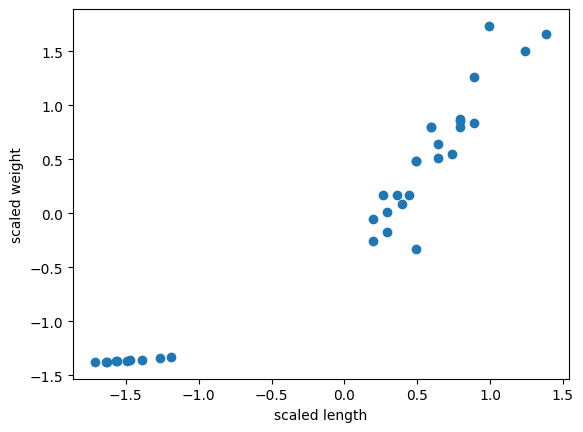

In [17]:
import matplotlib.pyplot as plt

scaled_lengths = [fish[0] for fish in train_scaled_manual]
scaled_weights = [fish[1] for fish in train_scaled_manual]

plt.scatter(scaled_lengths, scaled_weights)
plt.xlabel('scaled length')
plt.ylabel('scaled weight')
plt.show()

In [18]:
test_scaled_manual = []

for fish in test_input:
    scaled_length = (fish[0] - mean_length) / std_length
    scaled_weight = (fish[1] - mean_weight) / std_weight
    test_scaled_manual.append([scaled_length, scaled_weight])

print("스케일링된 테스트 첫 데이터:", test_scaled_manual[0])

스케일링된 테스트 첫 데이터: [-1.5893820108290353, -1.3655627122932026]


In [19]:
kn_scaled = KNeighborsClassifier()
kn_scaled.fit(train_scaled_manual, train_target)
scaled_score = kn_scaled.score(test_scaled_manual, test_target)

print("수동 스케일링 후 정확도:", scaled_score)

수동 스케일링 후 정확도: 1.0


In [20]:
new_fish = [25, 150]

new_scaled = [
    (new_fish[0] - mean_length) / std_length,
    (new_fish[1] - mean_weight) / std_weight
]

print("새 물고기 스케일링 결과:", new_scaled)
print("예측 결과:", kn_scaled.predict([new_scaled]))

새 물고기 스케일링 결과: [-0.20071490885653015, -0.9260418225794215]
예측 결과: [1.]


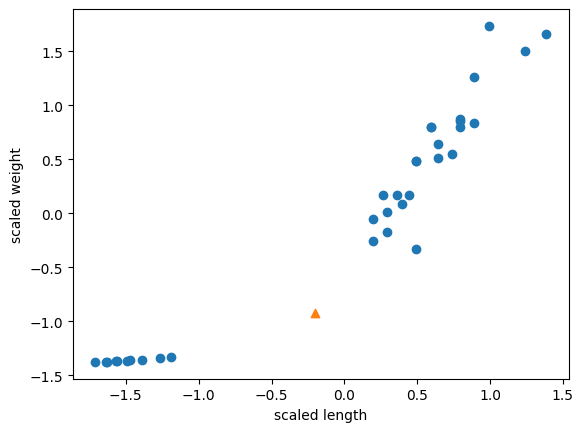

In [21]:
plt.scatter(scaled_lengths, scaled_weights)
plt.scatter(new_scaled[0], new_scaled[1], marker='^')
plt.xlabel('scaled length')
plt.ylabel('scaled weight')
plt.show()

In [22]:
if kn_scaled.predict([new_scaled])[0] == 1:
    print("[25, 150] -> 도미")
else:
    print("[25, 150] -> 빙어")

[25, 150] -> 도미
